## Table of Contents

- [Setup and Imports](#setup-imports)
- [Task 1: Exploratory Data Analysis](#task-1)
- [Task 2(a): Naive Bayes](#task-2a)
- [Task 2(b): k-Nearest Neighbours](#task-2b)
- [Task 2(c): Support Vector Machines](#task-2c)
- [Task 2(d): Artificial Neural Network](#task-2d)
- [Task 3(a): Hyperparameter Investigation For Each Classifier](#task-3a)
- [Task 3(b): Best Model Comparison on Test Set](#task-3b)
- [Task 3(c): Effect of Training Set Size](#task-3c)
- [Final Summary](#final-summary)

<a id="setup-imports"></a>
## Setup

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Imports for Exploratory Data Analysis
from sklearn.feature_extraction.text import CountVectorizer 
import heapq

# Imports for Naive Bayes
from sklearn.naive_bayes import MultinomialNB

# Imports for artificial neural network
from sklearn.neural_network import MLPClassifier
from sklearn.feature_extraction.text import TfidfVectorizer

# Imports for hyperparameter investigation
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold, validation_curve

# Imports for classifier evaluation
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score

# Constant
RANDOM_STATE = 42

<a id="task-1"></a>
## Task 1: Exploratory Data Analysis
We use `CountVectorizer` for the exploratory term-frequency analysis because the task asks us to analyse word counts in the train dataset. The article text has already been tokenized, lower-cased, and cleaned in the provided dataset.

### Task 1(a): Dataset size and extracted features
We first construct feature vectors for the train and test articles using `CountVectorizer`. The number of extracted features corresponds to the size of the vocabulary learned from the training dataset.

In [31]:
# Load the data
train_df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv')

# Construct count-based feature vectors
count_vectorizer = CountVectorizer()

X_train_counts = count_vectorizer.fit_transform(train_df["Article"])
X_test_counts = count_vectorizer.transform(test_df["Article"])

count_feature_names = count_vectorizer.get_feature_names_out()

In [32]:
feature_summary_df = pd.DataFrame({
    "Dataset": ["Train", "Test"],
    "Number of articles": [train_df.shape[0], test_df.shape[0]],
    "Number of extracted features": [X_train_counts.shape[1], X_test_counts.shape[1]]
})

display(feature_summary_df)

,Dataset,Number of articles,Number of extracted features
0,Train,428,13518
1,Test,106,13518


The train and test datasets are transformed using the same vocabulary learned from the training data. Therefore, both datasets have the same number of extracted features.

Next, we show five example articles with their extracted features. Since each article is represented by a large sparse vector, we display only the highest-count nonzero features for each article. This gives a readable view of what the feature vector contains without showing every vocabulary term.

In [33]:
def get_top_features_for_article(X, feature_names, row_index, top_n=10):

    # Convert this article's sparse feature vector into a dense 1D array of word counts
    row = X[row_index].toarray().ravel()
    
    nonzero_indices = np.where(row > 0)[0]
    nonzero_counts = row[nonzero_indices]
    
    sorted_indices = np.argsort(nonzero_counts)[::-1]
    top_indices = nonzero_indices[sorted_indices[:top_n]]
    
    return [(feature_names[i], int(row[i])) for i in top_indices]


example_rows = []

for i in range(5):
    article_features = get_top_features_for_article(X_train_counts, count_feature_names, i, top_n=10)

    example_rows.append({
        "Id": train_df.loc[i, "Id"],
        "Category": train_df.loc[i, "Category"],
        "Article preview": train_df.loc[i, "Article"][:120] + "...",
        "Top extracted features": article_features
    })

example_features_df = pd.DataFrame(example_rows)
display(example_features_df)

,Id,Category,Article preview,Top extracted features
0,1976,tech,lifestyle governs mobile choice faster better ...,"[(said, 12), (phone, 11), (people, 9), (use, 8..."
1,1797,entertainment,french honour director parker british film dir...,"[(film, 5), (director, 4), (sir, 3), (parker, ..."
2,1866,entertainment,fockers fuel festive film chart comedy meet fo...,"[(christmas, 6), (meet, 5), (fockers, 5), (day..."
3,1153,entertainment,housewives lift channel 4 ratings debut us tel...,"[(last, 5), (audience, 5), (channel, 4), (shar..."
4,342,entertainment,u2 desire number one u2 three prestigious gram...,"[(band, 9), (want, 5), (u2, 5), (album, 5), (s..."


### Task 1(b)(i): Top-50 term frequency distribution

First, we compute the total frequency of each term in the training dataset.

In [34]:
def get_top_terms_and_frequencies(term_counts, feature_names, top_n=50):
    top_indices = heapq.nlargest(
        top_n,
        range(len(term_counts)),
        key=lambda i: term_counts[i]
    )

    top_terms = []
    top_frequencies = []

    for i in top_indices:
        top_terms.append(feature_names[i])
        top_frequencies.append(int(term_counts[i]))

    return top_terms, top_frequencies

Then, we plot the 50 most frequent terms.

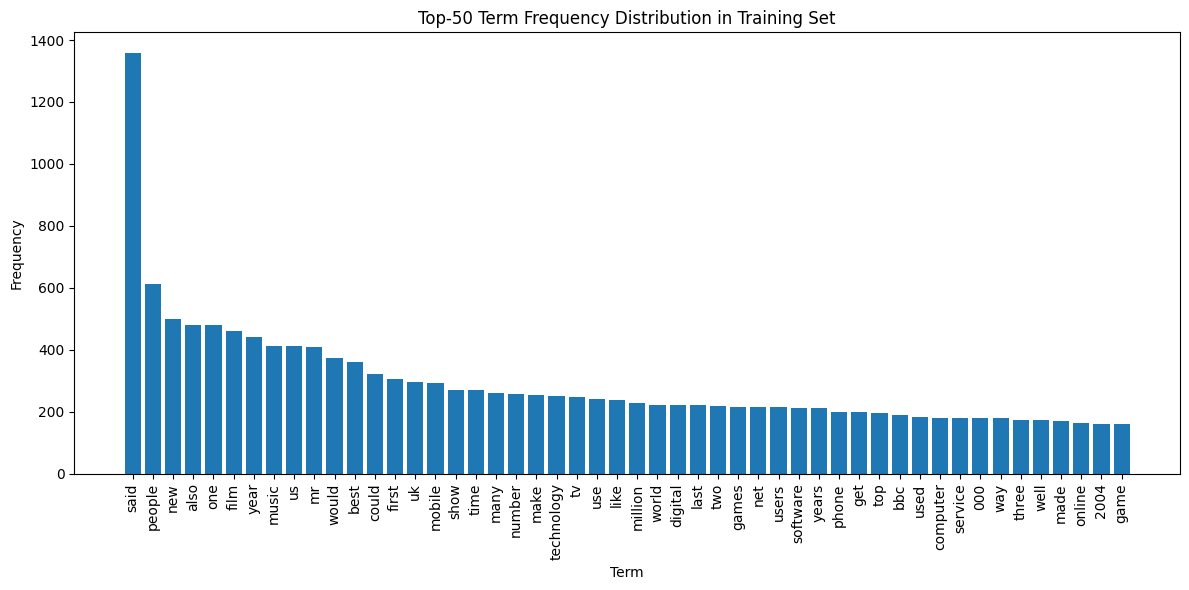

In [35]:
train_term_counts = np.asarray(X_train_counts.sum(axis=0)).ravel()

top_50_terms, top_50_frequencies = get_top_terms_and_frequencies(train_term_counts, count_feature_names, 50)

plt.figure(figsize=(12, 6))
plt.bar(top_50_terms, top_50_frequencies)
plt.xlabel("Term")
plt.ylabel("Frequency")
plt.title("Top-50 Term Frequency Distribution in Training Set")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Task 1(b)(ii): Term frequency distribution per class

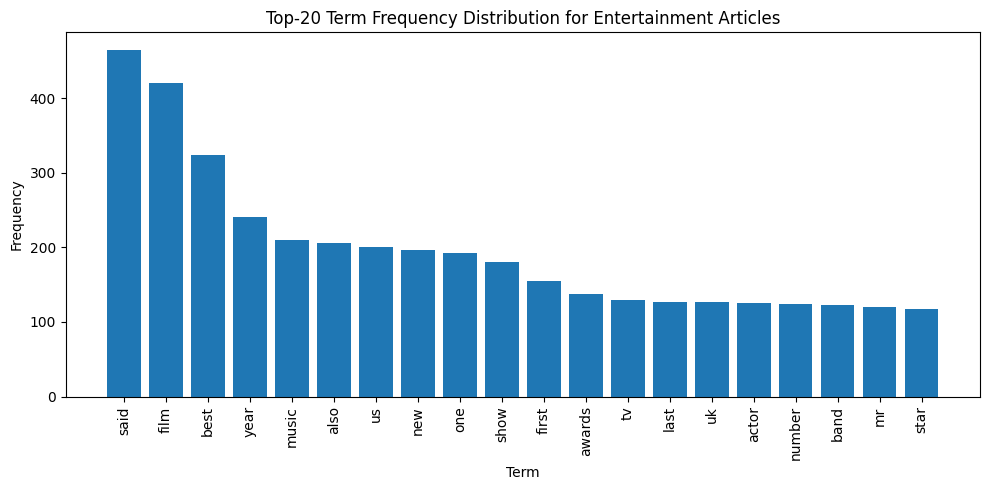

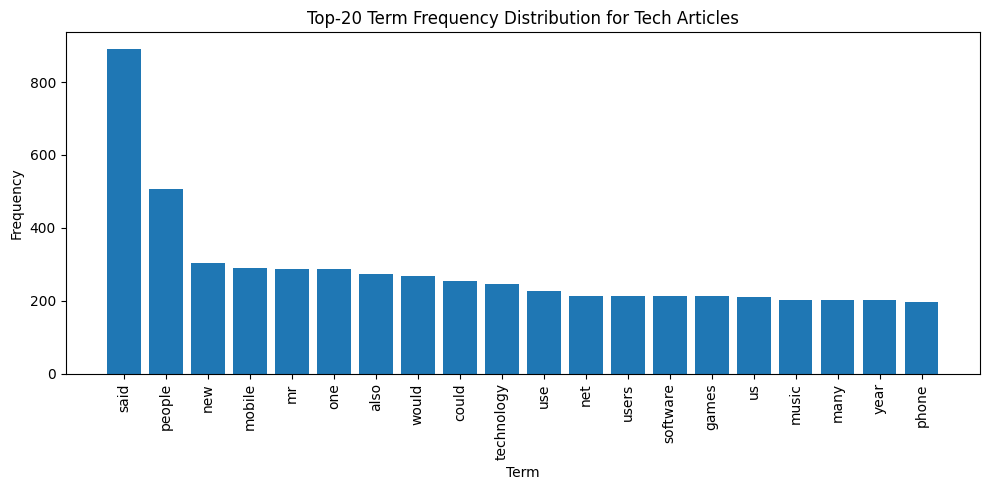

In [37]:
for category in sorted(train_df["Category"].unique()):

    # Convert the pandas boolean Series into a NumPy array so we can safely index the sparse matrix
    class_rows = (train_df["Category"] == category).to_numpy()
    class_term_counts = np.asarray(X_train_counts[class_rows].sum(axis=0)).ravel()

    top_terms, top_frequencies = get_top_terms_and_frequencies(class_term_counts, count_feature_names, 20)

    plt.figure(figsize=(10, 5))
    plt.bar(top_terms, top_frequencies)
    plt.xlabel("Term")
    plt.ylabel("Frequency")
    plt.title(f"Top-20 Term Frequency Distribution for {category.capitalize()} Articles")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

### Task 1(b)(iii): Class distribution for the training and testing set

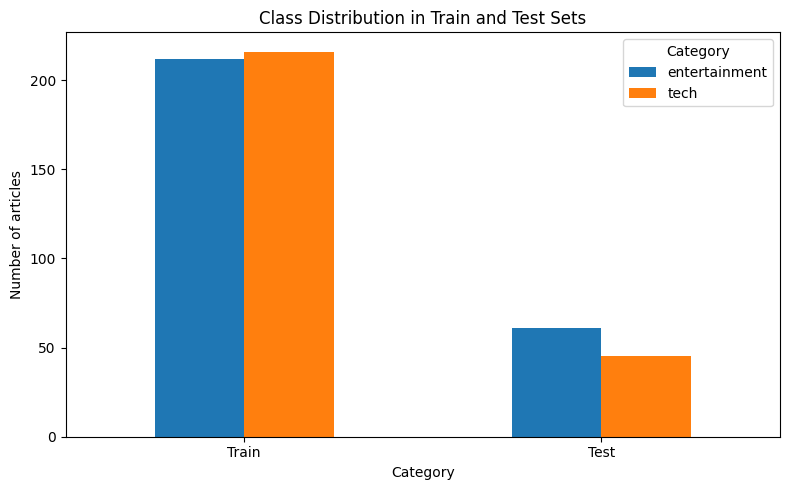

In [41]:
class_distribution_df = pd.DataFrame({
    "Train": train_df["Category"].value_counts(),
    "Test": test_df["Category"].value_counts()
}).T

class_distribution_df.plot(kind="bar", figsize=(8, 5))

plt.xlabel("Category")
plt.ylabel("Number of articles")
plt.title("Class Distribution in Train and Test Sets")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

The class distribution plot compares the number of entertainment and tech articles in the train and test datasets. The training set is much larger than the test set.

Within the training set, the two classes are represented in very similar amounts. The test set has more entertainment articles than tech articles, but both classes are still represented. Overall, there is no severe class imbalance between the two classes, which makes later model evaluation more straightforward.

<a id="task-2a"></a>
## Task 2(a): Naive Bayes

### Training the Naive Bayes model
Default Laplace smoothing (`alpha=1`) keeps every word probability non-zero needed for the ratio in (ii)

In [15]:
# Count features are used for Multinomial Naive Bayes because the model is based on term counts.
nb_vectorizer = CountVectorizer()
X_train_nb = nb_vectorizer.fit_transform(train_df["Article"])
X_test_nb = nb_vectorizer.transform(test_df["Article"])

# Feature names, effectively the "vocabulary"
nb_feature_names = nb_vectorizer.get_feature_names_out()

nb_model = MultinomialNB()
nb_model.fit(X_train_nb, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


### Top 20 predictive words per class

In [16]:
class_labels = nb_model.classes_
log_probabilities = nb_model.feature_log_prob_

top_n = 20

# Get the 20 words with the highest log probability within each class
top_words_by_class = {}

for class_index, class_label in enumerate(class_labels):
    top_indices = np.argsort(log_probabilities[class_index])[::-1][:top_n]
    top_words_by_class[class_label] = nb_feature_names[top_indices]

top_words_df = pd.DataFrame(top_words_by_class)
display(top_words_df)

,entertainment,tech
0,said,said
1,film,people
2,best,new
3,year,mobile
4,music,mr
5,also,one
6,us,also
7,new,would
8,one,could
9,show,technology


### Top 20 discriminative words

To better understand what the Naive Bayes model learned, we compare the conditional word probabilities for the `tech` and `entertainment` classes. For each word, we calculated the ratio:

`P(word | tech) / P(word | entertainment)`

A large ratio indicates that the word is much more strongly associated with tech articles than entertainment articles, while a very small ratio indicates the opposite. To make the comparison easier to interpret, I displayed the top tech-associated words on the left and the top entertainment-associated words on the right, using the reciprocal ratio for entertainment words.

This helps identify words that are not just common overall, but actually useful for distinguishing between the two classes.

In [17]:
tech_index = np.where(class_labels == "tech")[0][0]
entertainment_index = np.where(class_labels == "entertainment")[0][0]

# Compare how strongly each word is associated with tech versus entertainment.
# A high ratio means the word is much more common in tech articles than entertainment articles.
log_ratio = log_probabilities[tech_index] - log_probabilities[entertainment_index]
ratio = np.exp(log_ratio)

top_tech_word_indices = np.argsort(log_ratio)[::-1][:20]
top_entertainment_word_indices = np.argsort(log_ratio)[:20]

# Show the most discriminative words for tech on the left, and entertainment on the right.
discriminative_words_df = pd.DataFrame({
    "tech_word": nb_feature_names[top_tech_word_indices],
    "P(word|tech) / P(word|entertainment)": ratio[top_tech_word_indices].round(1),
    "entertainment_word": nb_feature_names[top_entertainment_word_indices],
    "P(word|entertainment) / P(word|tech)": (1 / ratio[top_entertainment_word_indices]).round(1)
})

display(discriminative_words_df)

,tech_word,P(word|tech) / P(word|entertainment),entertainment_word,P(word|entertainment) / P(word|tech)
0,users,157.3,actress,124.3
1,software,156.6,singer,123.0
2,microsoft,113.4,oscar,120.2
3,mobile,106.5,stars,103.9
4,broadband,94.4,aviator,86.1
5,virus,90.0,band,84.7
6,firms,83.4,nominated,75.2
7,pc,79.8,rock,72.4
8,spam,62.2,festival,72.4
9,phones,53.1,album,67.6


### Discussion

The top 20 predictive words per class are the words with the highest estimated conditional probability under that class. These lists include some meaningful class-related terms, but they can also contain generally frequent words.

The ratio-based discriminative list is more useful for distinguishing the classes because it compares how much more likely a word is under one class than the other. 

Words with a higher value of `P(word|tech) / P(word|entertainment)` are especially associated with tech articles rather than merely being frequent overall. Therefore, the discriminative ratio list better describes the difference between the two classes.

<a id="task-2d"></a>
## Task 2(d): Artificial Neural Network

For this task, we train a single-hidden-layer neural network on the training dataset.

The network uses the following required hyperparameters:

- Initial weights uniformly drawn from the range $[0, 0.1]$
- Learning rate: $0.01$
- Number of training epochs: $100$
- Hidden units: $h \in \{2, 5, 20, 40\}$

The input layer consists of the extracted text feature vector for each article:

$$
x = [x_1, x_2, \ldots, x_n]^T
$$

The hidden layer contains $h$ hidden units:

$$
z = [z_1, z_2, \ldots, z_h]^T
$$

The output layer gives a probability distribution over the two classes:

$$
y = [y_1, y_2]^T
$$

We train the model separately for each value of $h$, then plot the final binary cross-entropy loss on the training data against the number of hidden units. Finally, we briefly discuss how changing the number of hidden units affects the model.

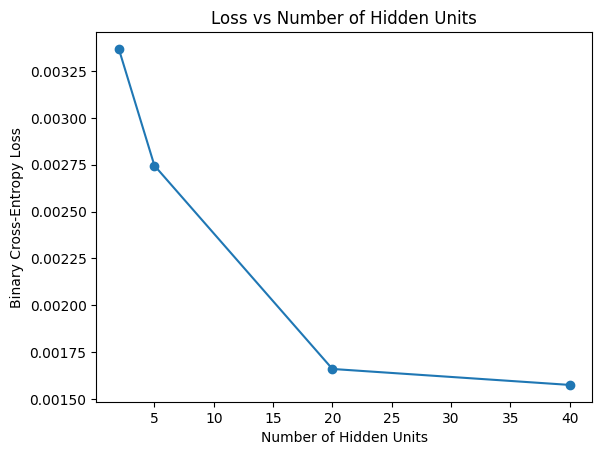

In [18]:
hidden_units = [2, 5, 20, 40]
losses = []

# Train the model with different numbers of hidden units and record the loss
for h in hidden_units:
    model = MLPClassifier(
        hidden_layer_sizes=(h,),
        learning_rate_init=0.01,
        max_iter=100,
        random_state=RANDOM_STATE
    )
    model.fit(X_train, y_train)
    losses.append(model.loss_)  # final training loss

# Plot the results
plt.plot(hidden_units, losses, marker='o')
plt.xlabel('Number of Hidden Units')
plt.ylabel('Binary Cross-Entropy Loss')
plt.title('Loss vs Number of Hidden Units')
plt.show()

### Report / Reasoning

As the number of hidden units increases, the training loss tends to decrease. This is because more hidden units give the model greater capacity to learn complex patterns in the data. However, beyond a certain point, the improvements become smaller, adding more units yields diminishing returns. Additionally, too many hidden units risks overfitting the model to the training data, which would hurt performance on unseen data.

## Task 3(a): Hyperparameter Investigation For Each Classifier with 5-Fold Cross-Validation

E.g., for SVM, the classification accuracy may be significantly affected by the kernels and associated hyperparameters. List hyperparameters for each classifier and demonstrate how these hyperparameters impact the model performance (cross-validation performance). [1 pt] 

## Desired Final Outputs from Task 3(a)

```python
best_nb_model
best_nb_params

best_knn_model
best_knn_params

best_svm_model
best_svm_params

best_ann_model
best_ann_params
```

Where each best_*_model is preferably a full pipeline.
Then task 3b) and 3c) can use and loop over:

```python
models = {
    "Naive Bayes": best_nb_model,
    "kNN": best_knn_model,
    "SVM": best_svm_model,
    "ANN": best_ann_model,
}
```

### Naive Bayes

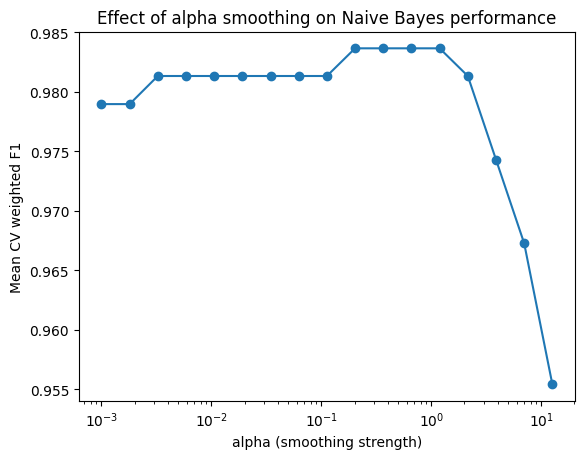

Best NB parameters: {'nb__alpha': 0.1, 'vectorizer__min_df': 2, 'vectorizer__ngram_range': (1, 2)}
Best mean CV F1: 0.9883


In [21]:
# Pipeline wraps the vectorizer and classifier together so cross-validation doesn't leak vocabulary
nb_pipeline = Pipeline([
    ("vectorizer", CountVectorizer()),
    ("nb", MultinomialNB())
])

stratified_k_fold = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Investigate the effect of alpha smoothing on cross-validation performance
alpha_values = np.logspace(-3, 1.1, 17)

_, validation_scores = validation_curve(
    nb_pipeline,
    train_df["Article"],
    y_train,
    param_name="nb__alpha",
    param_range=alpha_values,
    cv=stratified_k_fold,
    scoring="f1_weighted",
    n_jobs=-1
)

plt.semilogx(alpha_values, validation_scores.mean(axis=1), "o-")
plt.xlabel("alpha (smoothing strength)")
plt.ylabel("Mean CV weighted F1")
plt.title("Effect of alpha smoothing on Naive Bayes performance")
plt.show()


# Grid search over vocab settings and alpha to find the best parameter combination
nb_param_grid = {
    "vectorizer__ngram_range": [(1, 1), (1, 2)], # tests only single words vs single words and bigrams
    "vectorizer__min_df": [1, 2, 5],             # compares all words, words in atleast 2 documents, and then atleast 5
    "nb__alpha": [0.01, 0.1, 0.5, 1.0, 2.0]
}

nb_grid = GridSearchCV(
    nb_pipeline,
    nb_param_grid,
    cv=stratified_k_fold,
    scoring="f1_weighted",
    n_jobs=-1
)

nb_grid.fit(train_df["Article"], y_train)

print("Best NB parameters:", nb_grid.best_params_)
print("Best mean CV F1:", round(nb_grid.best_score_, 4))

For Naive Bayes, we investigated the smoothing parameter `alpha`, along with simple vectorizer settings such as `ngram_range` and `min_df`.

The smoothing parameter controls how much probability mass is assigned to rare or unseen words. Very small `alpha` values apply little smoothing, so rare words can have overly strong influence. 

Larger `alpha` values smooth the probabilities more heavily, which can improve robustness (tf does this mean) but may also weaken useful word-class associations. 

Based on 5-fold cross-validation, the best NB setting used alpha = 0.1. 

The selected vocabulary settings were min_df = 2 and ngram_range = (1, 2), suggesting that removing words appearing in only one document and including bigrams slightly improved cross-validation F1 for this split. 

However, the validation scores were close across several settings, so this improvement should be interpreted as modest rather than a large effect.

## Task 3(b): Comparison of Final Classifiers

(b) Report and compare your NB, kNN, SVM and NN classifiers with the best hyperparameter settings.
Summarize what you have observed in the classification accuracy in 𝐹1 measure on the testing dataset. [0.5 pt]

<strong>WILL DO WHEN ALL CLASSIFIERS ARE READY</strong>

## Task 3(c): Effect of training set size

Explore how the size of the training data set affects the test and train accuracy of NB, kNN, SVM and ANN classifiers with the best hyperparameter settings. 

For each value `m` in [0.1, 0.3, 0.5, 0.7, 0.9], train your classifier on the first `m` portion of the training instances (that is, `data[0:mN]`, assuming, data is dataframe with `N` training instances, as loaded from the provided file. 

Please report two plots: <br/>
(i) train accuracy, and <br/>
(ii) test accuracy 

for each such value of `m` with the x-axis referring to `m` and the y-axis referring to the classification accuracy as measured by <br/>
𝐹1 = 2(precision x recall) / (precision + recall). 

In total, there should be four curves for train accuracy and four curves for test accuracy. <br/>
Explain the general trend of the two plots in terms of training and testing accuracy if any. [2 pts]


### Naive Bayes

Cam already did 3c) for this, I will go back to it when I've put all the classifiers in.

All code below is not complete

In [23]:
# Define shared proportions
training_proportions = [0.1, 0.3, 0.5, 0.7, 0.9]

# Define a reusable training-size evaluator
from sklearn.base import clone

def evaluate_training_size_text_model(model, X_train_text, y_train, X_test_text, y_test, proportions):
    train_f1_scores = []
    test_f1_scores = []

    n = len(X_train_text)

    for m in proportions:
        end = int(m * n)

        X_subset = X_train_text.iloc[:end]
        y_subset = y_train.iloc[:end] if hasattr(y_train, "iloc") else y_train[:end] # what's the point of this?

        model_clone = clone(model)
        model_clone.fit(X_subset, y_subset)

        train_pred = model_clone.predict(X_subset)
        test_pred = model_clone.predict(X_test_text)

        train_f1_scores.append(f1_score(y_subset, train_pred, average="weighted"))
        test_f1_scores.append(f1_score(y_test, test_pred, average="weighted"))

    return train_f1_scores, test_f1_scores

In [24]:
# Get NB training-size results
nb_train_f1, nb_test_f1_by_size = evaluate_training_size_text_model(
    best_nb_model,
    train_df["Article"],
    y_train,
    test_df["Article"],
    y_test,
    training_proportions
)

nb_training_size_df = pd.DataFrame({
    "m": training_proportions,
    "NB train F1": nb_train_f1,
    "NB test F1": nb_test_f1_by_size
})

display(nb_training_size_df)

NameError: name 'best_nb_model' is not defined